In [67]:
import pandas as pd
import torch
import numpy as np
from cgmvae import*
from torch.nn import functional as F
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
# load original input data
# actually we don't really need to do this unless we're interested in accuracy of reconstruction too, but we don't necessarily need to be 
# load latent variables 
latent_features_train = pd.read_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/cfc_pred/shap_analysis/train_df.csv')
latent_features_train

,LV1,LV2,LV3,LV4,LV5,mouse_ids,Diet,Mouse.ID,CFC.24mo.Average
0,1.648254,1.558364,1.450668,1.713205,1.723632,DO-1D-3168,1D,DO-1D-3168,-0.820451
1,-0.794890,-1.137012,-1.105946,-0.938151,-0.875722,DO-40-2083,40,DO-40-2083,0.780704
2,-0.348093,-0.264138,-0.208897,-0.409450,-0.600421,DO-20-1186,20,DO-20-1186,0.452638
3,0.956853,1.063802,1.653756,1.514652,1.608262,DO-1D-3059,1D,DO-1D-3059,1.698389
4,1.407127,1.454008,1.323928,1.397264,1.267337,DO-40-2002,40,DO-40-2002,-0.582971
...,...,...,...,...,...,...,...,...,...
398,-0.890301,-0.859367,-0.897388,-0.965282,-0.967811,DO-1D-3185,1D,DO-1D-3185,-1.763434
399,-0.481943,-0.825826,-0.808517,-0.631954,-0.711390,DO-2D-4058,2D,DO-2D-4058,0.951265
400,1.344620,1.542254,1.234269,1.474108,1.414498,DO-20-1053,20,DO-20-1053,-0.787807
401,0.919085,0.931402,1.518434,1.483853,1.381329,DO-20-1044,20,DO-20-1044,1.624125


In [3]:
data_with_cfc_labels = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/data_with_cfc_5bins.csv')
data_with_cfc_labels = data_with_cfc_labels[['MouseID', 'cfc_bin']]
data_with_cfc_labels

,MouseID,cfc_bin
0,DO-40-2162,0
1,DO-40-2179,1
2,DO-40-2181,1
3,DO-40-2187,2
4,DO-40-2099,1
...,...,...
499,DO-2D-4007,1
500,DO-1D-3030,1
501,DO-20-1021,0
502,DO-AL-0002,2


In [4]:
saved_model_path = '/Users/racheliritani/Desktop/AD Project/mm-vae/results_DIET/CGMVAE_cfc_cond_5bins_5dim/saved_model_epoch5000.pth'

In [5]:
accelerator = True 

if accelerator:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [6]:
#vae = CGMVAE()
vae = torch.load(saved_model_path, map_location=device)
vae.to(device)
vae.eval()

CGMVAE(
  (label): Embedding(5, 1)
  (fc1): Linear(in_features=37, out_features=16, bias=True)
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc21): Linear(in_features=16, out_features=25, bias=True)
  (fc22): Linear(in_features=16, out_features=25, bias=True)
  (fc3): Linear(in_features=6, out_features=16, bias=True)
  (bn3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=16, out_features=36, bias=True)
)

## Doing analysis with LV5 conditonal label 0

In [7]:
mouse_ids_0 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 0]['MouseID'].tolist()
latent_features_train_0 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_0)]
latent_features_train_0 = latent_features_train_0[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_0

,LV1,LV2,LV3,LV4,LV5
13,-0.893698,-0.720176,-0.866757,-0.823112,-1.094731
14,-1.622135,-1.356036,-1.420345,-1.495535,-1.267595
23,-0.957110,-0.818695,-0.948691,-0.993643,-0.997910
25,-1.577005,-1.315113,-1.407930,-1.409376,-1.314672
30,-1.276818,-1.093347,-1.127115,-1.167925,-0.975741
...,...,...,...,...,...
388,-1.436359,-1.235382,-1.249746,-1.297314,-0.932213
389,-1.141634,-0.943330,-0.982594,-1.051950,-0.920841
390,-1.327842,-1.144189,-1.166487,-1.188210,-1.019409
394,-1.513083,-1.272883,-1.293408,-1.326203,-1.131958


In [8]:
latent_features_train_mean_0 = latent_features_train_0.mean()
latent_features_train_mean_0

LV1   -1.348009
LV2   -1.133437
LV3   -1.187552
LV4   -1.229302
LV5   -1.090288
dtype: float64

In [9]:
min(latent_features_train_0['LV4']), max(latent_features_train_0['LV4'])

(-1.5200808973174, -0.594987841288106)

In [10]:
lv_traversal_values_0 = [-2, -1.5, -1, -0.5, 0]
latent_features_train_neg2_0 = latent_features_train_mean_0.copy()
latent_features_train_neg2_0.iloc[3] = lv_traversal_values_0[0]
latent_features_train_neg1_0 = latent_features_train_mean_0.copy()
latent_features_train_neg1_0.iloc[3] = lv_traversal_values_0[1]
latent_features_train_zero_0 = latent_features_train_mean_0.copy()
latent_features_train_zero_0.iloc[3] = lv_traversal_values_0[2]
latent_features_train_one_0 = latent_features_train_mean_0.copy()
latent_features_train_one_0.iloc[3] = lv_traversal_values_0[3]
latent_features_train_two_0 = latent_features_train_mean_0.copy()
latent_features_train_two_0.iloc[3] = lv_traversal_values_0[4]

In [11]:
stacked_data_input_0 = np.vstack((latent_features_train_neg2_0, latent_features_train_neg1_0, latent_features_train_zero_0, latent_features_train_one_0, latent_features_train_two_0))
stacked_data_input_0

array([[-1.34800858, -1.13343743, -1.18755181, -2.        , -1.09028788],
       [-1.34800858, -1.13343743, -1.18755181, -1.5       , -1.09028788],
       [-1.34800858, -1.13343743, -1.18755181, -1.        , -1.09028788],
       [-1.34800858, -1.13343743, -1.18755181, -0.5       , -1.09028788],
       [-1.34800858, -1.13343743, -1.18755181,  0.        , -1.09028788]])

In [12]:
z_traversal_0 = torch.tensor(stacked_data_input_0, dtype=torch.float32).to(device)
#y_labels = torch.tensor(np.ones(5), dtype=torch.long).to(device)
y_labels_0 = torch.tensor(np.zeros(5), dtype=torch.long).to(device)

## Prepare data for transversing LV5 with conditional label 1

In [13]:
mouse_ids_1 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 1]['MouseID'].tolist()
latent_features_train_1 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_1)]
latent_features_train_1 = latent_features_train_1[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_1

,LV1,LV2,LV3,LV4,LV5
0,1.648254,1.558364,1.450668,1.713205,1.723632
4,1.407127,1.454008,1.323928,1.397264,1.267337
15,1.219892,0.858839,0.811899,0.836143,0.712234
19,1.642225,1.663701,1.346894,1.761315,1.741227
21,1.510944,1.577664,1.146596,1.492334,1.343644
...,...,...,...,...,...
385,1.290042,1.164315,0.996189,1.291856,1.241618
387,1.512038,1.343424,1.239869,1.575708,1.555214
393,1.460973,1.360372,1.296377,1.578111,1.540010
400,1.344620,1.542254,1.234269,1.474108,1.414498


In [14]:
latent_features_train_mean_1 = latent_features_train_1.mean()
latent_features_train_mean_1

LV1    1.338759
LV2    1.337852
LV3    1.042993
LV4    1.238350
LV5    1.175304
dtype: float64

In [15]:
min(latent_features_train_1['LV4']), max(latent_features_train_1['LV4'])

(0.1881473425768822, 1.8219426087132)

In [16]:
lv_traversal_values_1 = [0, 0.5, 1, 1.5, 2]
latent_features_train_neg2_1 = latent_features_train_mean_1.copy()
latent_features_train_neg2_1.iloc[3] = lv_traversal_values_1[0]
latent_features_train_neg1_1 = latent_features_train_mean_1.copy()
latent_features_train_neg1_1.iloc[3] = lv_traversal_values_1[1]
latent_features_train_zero_1 = latent_features_train_mean_1.copy()
latent_features_train_zero_1.iloc[3] = lv_traversal_values_1[2]
latent_features_train_one_1 = latent_features_train_mean_1.copy()
latent_features_train_one_1.iloc[3] = lv_traversal_values_1[3]
latent_features_train_two_1 = latent_features_train_mean_1.copy()
latent_features_train_two_1.iloc[3] = lv_traversal_values_1[4]

In [17]:
stacked_data_input_1 = np.vstack((latent_features_train_neg2_1, latent_features_train_neg1_1, latent_features_train_zero_1, latent_features_train_one_1, latent_features_train_two_1))
stacked_data_input_1

array([[1.33875905, 1.33785187, 1.04299338, 0.        , 1.17530418],
       [1.33875905, 1.33785187, 1.04299338, 0.5       , 1.17530418],
       [1.33875905, 1.33785187, 1.04299338, 1.        , 1.17530418],
       [1.33875905, 1.33785187, 1.04299338, 1.5       , 1.17530418],
       [1.33875905, 1.33785187, 1.04299338, 2.        , 1.17530418]])

In [18]:
z_traversal_1 = torch.tensor(stacked_data_input_1, dtype=torch.float32).to(device)
y_labels_1 = torch.tensor(np.ones(5), dtype=torch.long).to(device)

# Prepare data for traversing LV5 with conditional label 2

In [19]:
mouse_ids_2 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 2]['MouseID'].tolist()
latent_features_train_2 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_2)]
latent_features_train_2 = latent_features_train_2[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_2

,LV1,LV2,LV3,LV4,LV5
2,-0.348093,-0.264138,-0.208897,-0.409450,-0.600421
5,0.035996,0.163485,0.447772,0.348364,0.387066
7,0.014778,-0.089215,0.067121,-0.068191,-0.177578
10,-0.055891,-0.020498,0.081582,-0.034955,-0.152137
11,0.142019,0.236467,0.418668,0.282368,0.217389
...,...,...,...,...,...
370,-0.149577,-0.281372,-0.351628,-0.525232,-0.632906
380,-0.082595,-0.111938,0.116845,-0.013294,0.003919
382,-0.117836,-0.044868,-0.031371,-0.131411,-0.181905
395,-0.126171,-0.197896,-0.105915,-0.251575,-0.388558


In [20]:
latent_features_train_mean_2 = latent_features_train_2.mean()
latent_features_train_mean_2

LV1   -0.110642
LV2   -0.064196
LV3    0.047799
LV4   -0.086370
LV5   -0.156310
dtype: float64

In [21]:
min(latent_features_train_2['LV4']), max(latent_features_train_2['LV4'])

(-0.6121007023176637, 0.7871511852988649)

In [22]:
lv_traversal_values_2 = [-1, -0.5, 0, 0.5, 1]
latent_features_train_neg2_2 = latent_features_train_mean_2.copy()
latent_features_train_neg2_2.iloc[3] = lv_traversal_values_2[0]
latent_features_train_neg1_2 = latent_features_train_mean_2.copy()
latent_features_train_neg1_2.iloc[3] = lv_traversal_values_2[1]
latent_features_train_zero_2 = latent_features_train_mean_2.copy()
latent_features_train_zero_2.iloc[3] = lv_traversal_values_2[2]
latent_features_train_one_2 = latent_features_train_mean_2.copy()
latent_features_train_one_2.iloc[3] = lv_traversal_values_2[3]
latent_features_train_two_2 = latent_features_train_mean_2.copy()
latent_features_train_two_2.iloc[3] = lv_traversal_values_2[4]

In [23]:
stacked_data_input_2 = np.vstack((latent_features_train_neg2_2, latent_features_train_neg1_2, latent_features_train_zero_2, latent_features_train_one_2, latent_features_train_two_2))
stacked_data_input_2

array([[-0.11064207, -0.06419645,  0.0477987 , -1.        , -0.15630968],
       [-0.11064207, -0.06419645,  0.0477987 , -0.5       , -0.15630968],
       [-0.11064207, -0.06419645,  0.0477987 ,  0.        , -0.15630968],
       [-0.11064207, -0.06419645,  0.0477987 ,  0.5       , -0.15630968],
       [-0.11064207, -0.06419645,  0.0477987 ,  1.        , -0.15630968]])

In [24]:
z_traversal_2 = torch.tensor(stacked_data_input_2, dtype=torch.float32).to(device)
y_labels_2 = torch.tensor(np.ones(5) * 2, dtype=torch.long).to(device)

# Prepare data for traversing LV5 with conditional label 3

In [25]:
mouse_ids_3 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 3]['MouseID'].tolist()
latent_features_train_3 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_3)]
latent_features_train_3 = latent_features_train_3[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_3

,LV1,LV2,LV3,LV4,LV5
1,-0.794890,-1.137012,-1.105946,-0.938151,-0.875722
6,-0.577949,-0.922756,-0.905568,-0.737581,-0.774369
8,-0.475260,-0.876369,-0.796801,-0.632104,-0.687762
16,-0.541115,-0.852015,-0.859629,-0.709350,-0.757850
26,-0.231526,-0.615353,-0.641229,-0.464054,-0.702358
...,...,...,...,...,...
377,-0.056066,-0.411063,-0.400782,-0.268354,-0.583646
379,-0.888835,-1.038130,-1.258650,-1.086238,-1.199128
386,-0.406040,-0.840978,-0.788157,-0.581329,-0.696034
397,-0.521439,-0.892044,-0.884971,-0.669015,-0.744653


In [26]:
latent_features_train_mean_3 = latent_features_train_3.mean()
latent_features_train_mean_3

LV1   -0.560520
LV2   -0.896860
LV3   -0.899536
LV4   -0.714436
LV5   -0.797925
dtype: float64

In [27]:
min(latent_features_train_3['LV4']), max(latent_features_train_3['LV4'])

(-1.106233083749288, -0.2683542285279009)

In [28]:
lv_traversal_values_3 = [-1.5, -1, -0.5, -0, 0.5]
latent_features_train_neg2_3 = latent_features_train_mean_3.copy()
latent_features_train_neg2_3.iloc[3] = lv_traversal_values_3[0]
latent_features_train_neg1_3 = latent_features_train_mean_3.copy()
latent_features_train_neg1_3.iloc[3] = lv_traversal_values_3[1]
latent_features_train_zero_3 = latent_features_train_mean_3.copy()
latent_features_train_zero_3.iloc[3] = lv_traversal_values_3[2]
latent_features_train_one_3 = latent_features_train_mean_3.copy()
latent_features_train_one_3.iloc[3] = lv_traversal_values_3[3]
latent_features_train_two_3 = latent_features_train_mean_3.copy()
latent_features_train_two_3.iloc[3] = lv_traversal_values_3[4]

In [29]:
stacked_data_input_3 = np.vstack((latent_features_train_neg2_3, latent_features_train_neg1_3, latent_features_train_zero_3, latent_features_train_one_3, latent_features_train_two_3))
stacked_data_input_3

array([[-0.56051965, -0.89686036, -0.89953568, -1.5       , -0.79792473],
       [-0.56051965, -0.89686036, -0.89953568, -1.        , -0.79792473],
       [-0.56051965, -0.89686036, -0.89953568, -0.5       , -0.79792473],
       [-0.56051965, -0.89686036, -0.89953568,  0.        , -0.79792473],
       [-0.56051965, -0.89686036, -0.89953568,  0.5       , -0.79792473]])

In [30]:
z_traversal_3 = torch.tensor(stacked_data_input_3, dtype=torch.float32).to(device)
y_labels_3 = torch.tensor(np.ones(5) * 3, dtype=torch.long).to(device)

# Prepare data for traversing LV5 with conditional label 4

In [31]:
mouse_ids_4 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 4]['MouseID'].tolist()
latent_features_train_4 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_4)]
latent_features_train_4 = latent_features_train_4[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]

In [32]:
latent_features_train_mean_4 = latent_features_train_4.mean()
latent_features_train_mean_4

LV1    0.930291
LV2    1.044031
LV3    1.538322
LV4    1.168438
LV5    1.401014
dtype: float64

In [33]:
min(latent_features_train_4['LV4']), max(latent_features_train_4['LV4'])

(0.502670879268343, 1.7703206959245752)

In [34]:
lv_traversal_values_4 = [0, 0.5, 1, 1.5, 2]
latent_features_train_neg2_4 = latent_features_train_mean_4.copy()
latent_features_train_neg2_4.iloc[3] = lv_traversal_values_4[0]
latent_features_train_neg1_4 = latent_features_train_mean_4.copy()
latent_features_train_neg1_4.iloc[3] = lv_traversal_values_4[1]
latent_features_train_zero_4 = latent_features_train_mean_4.copy()
latent_features_train_zero_4.iloc[3] = lv_traversal_values_4[2]
latent_features_train_one_4 = latent_features_train_mean_4.copy()
latent_features_train_one_4.iloc[3] = lv_traversal_values_4[3]
latent_features_train_two_4 = latent_features_train_mean_4.copy()
latent_features_train_two_4.iloc[3] = lv_traversal_values_4[4]

In [35]:
stacked_data_input_4 = np.vstack((latent_features_train_neg2_4, latent_features_train_neg1_4, latent_features_train_zero_4, latent_features_train_one_4, latent_features_train_two_4))
stacked_data_input_4

array([[0.93029123, 1.0440314 , 1.53832194, 0.        , 1.40101444],
       [0.93029123, 1.0440314 , 1.53832194, 0.5       , 1.40101444],
       [0.93029123, 1.0440314 , 1.53832194, 1.        , 1.40101444],
       [0.93029123, 1.0440314 , 1.53832194, 1.5       , 1.40101444],
       [0.93029123, 1.0440314 , 1.53832194, 2.        , 1.40101444]])

In [36]:
z_traversal_4 = torch.tensor(stacked_data_input_4, dtype=torch.float32).to(device)
y_labels_4 = torch.tensor(np.ones(5) * 4, dtype=torch.long).to(device)

# Get mean and std for unstandardizing 

In [38]:
# Using training data to extract the mean and standardizing for our "unstandardizing"
cgmvae_train_data = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/train_data_with_cfc_5bins.csv')
cgmvae_train_data_features = cgmvae_train_data.iloc[:, 1:-5]
cgmvae_train_data_features

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,28,1557,30.432753,23.594599,23.529931,161.043852,71.901384,69.226421,495.841743,501.256947,...,1.822722,0.348339,0.747802,291.910043,181.741358,208.833723,0.183285,0.231782,0.235033,1
1,28,1520,25.977819,29.254446,30.242503,127.747193,85.358891,71.148922,466.210754,464.586935,...,0.999795,1.146192,0.924488,145.679543,223.139358,208.833223,0.106295,0.174654,0.216059,1
2,26,1638,24.242912,23.626717,22.912834,166.520150,72.692867,59.960123,464.789558,574.873297,...,1.044482,1.776962,2.179152,261.760471,173.953709,153.357082,0.110173,0.155822,0.285573,1
3,28,1406,24.467278,25.248257,23.109300,164.713839,87.471495,73.518078,467.014292,562.596065,...,1.680998,0.523920,0.894472,172.757669,113.888445,116.420115,0.104875,0.186652,0.231596,1
4,27,1463,27.809766,25.863157,26.732366,158.296170,79.935074,89.493029,460.859469,452.538921,...,1.255751,1.035345,0.902079,232.284376,238.633857,250.015922,0.106669,0.199779,0.104132,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398,22,825,26.553743,38.871831,38.162515,88.072095,132.803099,261.476515,457.706405,636.333799,...,1.327876,-0.250994,-2.736010,144.637287,200.397753,58.352082,0.301015,0.221042,0.555556,5
399,22,811,29.286695,34.668011,28.691245,145.238675,123.017597,261.476515,487.109521,459.643424,...,0.292768,1.503025,-2.736010,122.680287,147.980753,58.352082,0.301015,0.193995,0.555556,4
400,22,790,20.955567,32.435192,67.590983,135.481563,148.935317,261.476515,471.297011,513.299191,...,-0.505758,2.390828,-2.736010,128.851073,144.305810,58.352082,0.301015,0.188242,0.555556,4
401,22,748,24.315156,29.916707,67.590983,139.326564,136.439061,261.476515,544.317015,474.787570,...,3.246833,0.934841,-2.736010,223.713073,138.051810,58.352082,0.301015,0.082493,0.555556,4


In [39]:
all_input_features = cgmvae_train_data_features.columns
all_input_features

Index(['Generation', 'SurvDays', 'Y1A_BW_BW', 'Y2A_BW_BW', 'Y3A_BW_BW',
       'Y1_Glu.F_Glucose', 'Y2_Glu.F_Glucose', 'Y3_Glu.F_Glucose',
       'Y1_Echo_BPM', 'Y2_Echo_BPM', 'Y3_Echo_BPM', 'Y1_Echo_CardiacOutput',
       'Y2_Echo_CardiacOutput', 'Y3_Echo_CardiacOutput', 'Y1_CBC_Hgb',
       'Y2_CBC_Hgb', 'Y3_CBC_Hgb', 'Y1_Rotarod_Mean', 'Y2_Rotarod_Mean',
       'Y3_Rotarod_Mean', 'Y1_AS_MeanLog', 'Y2_AS_MeanLog', 'Y3_AS_MeanLog',
       'Y1_Wheel_AvgSpeedLFC', 'Y2_Wheel_AvgSpeedLFC', 'Y3_Wheel_AvgSpeedLFC',
       'Y1_Wheel_AvgDistLFC', 'Y2_Wheel_AvgDistLFC', 'Y3_Wheel_AvgDistLFC',
       'Y1A_Grip_All', 'Y2A_Grip_All', 'Y3A_Grip_All',
       'Y1A_Frailty_FrailtyAdj', 'Y2A_Frailty_FrailtyAdj',
       'Y3A_Frailty_FrailtyAdj', 'Diet_num'],
      dtype='object')

In [40]:
col_means = cgmvae_train_data_features.mean()
col_means.shape

(36,)

In [41]:
col_std = cgmvae_train_data_features.std()
col_std.shape

(36,)

# Run decoding on each conditional feature 

In [42]:
with torch.no_grad():
    # y_emb = vae.label(y_labels)

    # x = torch.cat((z_traversal, y_emb), dim=1)

    # h3_linear = vae.fc3(x)
    # h3_bn = vae.bn3(h3_linear)
    # h3_act = F.tanh(h3_bn)
    
    # vae.fc4(h3_act)
    reconstructions_standardized_0 = vae.decode(z_traversal_0, y_labels_0)
    reconstructions_standardized_1 = vae.decode(z_traversal_1, y_labels_1)
    reconstructions_standardized_2 = vae.decode(z_traversal_2, y_labels_2)
    reconstructions_standardized_3 = vae.decode(z_traversal_3, y_labels_3)
    reconstructions_standardized_4 = vae.decode(z_traversal_4, y_labels_4)

In [43]:
col_means_tensor = torch.tensor(col_means.values, dtype=torch.float32).to(device)
col_std_tensor = torch.tensor(col_std.values, dtype=torch.float32).to(device)

# Doing analysis for LV5 traversal with conditional label 0

In [44]:
unstandardized_data_tensor_0 = reconstructions_standardized_0 * col_std_tensor
unstandardized_data_tensor_0 = unstandardized_data_tensor_0 + col_means_tensor

In [46]:
reconstructions_unstandardized_df_0 = pd.DataFrame(unstandardized_data_tensor_0.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_0

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,24.102251,1014.298523,29.257238,39.597610,37.059696,192.780518,152.788971,158.886688,542.554565,538.659668,...,1.970153,1.439610,-1.121152,169.344040,177.273163,133.830917,0.189328,0.222963,0.306392,3.371336
1,24.144316,1012.871399,29.250986,39.599060,37.015266,192.704514,152.892700,159.106964,542.350464,538.654663,...,1.967062,1.440164,-1.148585,170.519608,177.444794,133.889923,0.188760,0.222628,0.307010,3.376640
2,24.186302,1011.457581,29.243309,39.598675,36.967991,192.615784,152.986969,159.323395,542.127319,538.643555,...,1.963688,1.440649,-1.176045,171.702942,177.619919,133.944504,0.188207,0.222283,0.307642,3.381930
3,24.228130,1010.059631,29.234110,39.596600,36.918228,192.514145,153.072006,159.536255,541.885864,538.626709,...,1.960037,1.441052,-1.203444,172.891174,177.798569,133.994019,0.187669,0.221930,0.308289,3.387222
4,24.269718,1008.680054,29.223293,39.593014,36.866413,192.399445,153.148300,159.746063,541.627136,538.604309,...,1.956117,1.441359,-1.230690,174.081207,177.980774,134.037659,0.187144,0.221570,0.308952,3.392537


In [47]:
reconstructions_standardized_df_0 = pd.DataFrame(reconstructions_standardized_0.cpu(), columns=all_input_features)
reconstructions_standardized_df_0

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.445875,0.037078,0.659072,0.789012,0.125656,1.025214,0.700786,0.100766,0.726562,0.761920,...,0.191323,0.095424,0.165377,-0.476295,0.238086,0.179105,0.491828,0.613236,-0.010483,0.401341
1,-0.427475,0.028992,0.657759,0.789182,0.122406,1.023122,0.703572,0.103860,0.722556,0.761817,...,0.188982,0.095783,0.151070,-0.448433,0.242797,0.180357,0.484546,0.605933,-0.006013,0.405194
2,-0.409110,0.020982,0.656145,0.789137,0.118947,1.020681,0.706103,0.106900,0.718176,0.761592,...,0.186427,0.096099,0.136750,-0.420388,0.247603,0.181515,0.477455,0.598418,-0.001440,0.409037
3,-0.390813,0.013062,0.654213,0.788894,0.115306,1.017884,0.708386,0.109891,0.713436,0.761248,...,0.183662,0.096361,0.122461,-0.392227,0.252505,0.182565,0.470549,0.590720,0.003237,0.412881
4,-0.372622,0.005245,0.651939,0.788474,0.111514,1.014728,0.710435,0.112838,0.708357,0.760794,...,0.180692,0.096561,0.108252,-0.364023,0.257506,0.183491,0.463818,0.582871,0.008023,0.416742


In [48]:
z_min = reconstructions_standardized_df_0.iloc[0]
z_max = reconstructions_standardized_df_0.iloc[-1]
difference_lv5_0 = np.abs(z_max - z_min)
difference_lv5_0_ranked = difference_lv5_0.sort_values(ascending=False)
difference_lv5_0_ranked.head(10)

Y1A_Grip_All             0.112272
Generation               0.073253
Y3_AS_MeanLog            0.064948
Y3_Wheel_AvgSpeedLFC     0.063763
Y3_CBC_Hgb               0.059444
Y3_Wheel_AvgDistLFC      0.057125
Y3_Echo_CardiacOutput    0.053897
Y3_Echo_BPM              0.053166
Y2_AS_MeanLog            0.050698
Y3_Rotarod_Mean          0.040893
dtype: float32

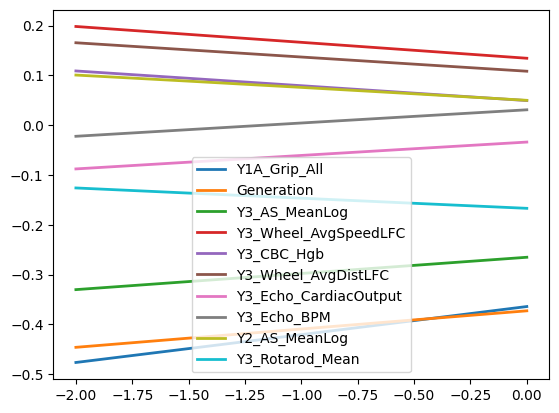

In [49]:
for col_name in difference_lv5_0_ranked.head(10).index.tolist(): 
    plt.plot(
        lv_traversal_values_0, 
        reconstructions_standardized_df_0[col_name], 
        label=col_name, 
        linewidth=2
    )
    plt.legend()

# Doing analysis for LV5 traversal with conditional label 1

In [50]:
unstandardized_data_tensor_1 = reconstructions_standardized_1 * col_std_tensor
unstandardized_data_tensor_1 = unstandardized_data_tensor_1 + col_means_tensor

In [51]:
reconstructions_unstandardized_df_1 = pd.DataFrame(unstandardized_data_tensor_1.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_1

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,22.167139,1145.716553,27.164787,32.074615,25.329945,162.270889,115.042572,114.455978,497.497833,516.863892,...,1.489287,1.313824,-0.311439,147.579208,172.668732,136.271103,0.267328,0.198765,0.253023,2.542855
1,22.191883,1143.860596,27.165131,32.178658,25.481756,162.463654,115.498367,115.206619,497.751129,517.188599,...,1.490090,1.313710,-0.322785,148.070023,172.878571,136.051361,0.266539,0.199075,0.254598,2.559416
2,22.215410,1142.063232,27.161463,32.284588,25.638634,162.637711,115.959618,115.959396,498.017761,517.514832,...,1.490921,1.313344,-0.332357,148.516998,173.092545,135.822433,0.265724,0.199404,0.256176,2.576521
3,22.237715,1140.320923,27.153675,32.392662,25.801037,162.793198,116.427086,116.716469,498.299072,517.843506,...,1.491779,1.312705,-0.340140,148.919693,173.311172,135.582596,0.264882,0.199752,0.257763,2.594218
4,22.258791,1138.631104,27.141670,32.503109,25.969378,162.930237,116.901482,117.479782,498.596130,518.175232,...,1.492666,1.311777,-0.346128,149.277740,173.534927,135.330261,0.264011,0.200121,0.259362,2.612549


In [52]:
reconstructions_standardized_df_1 = pd.DataFrame(reconstructions_standardized_1.cpu(), columns=all_input_features)
reconstructions_standardized_df_1

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-1.292326,0.781671,0.219375,-0.091657,-0.732582,0.185690,-0.312805,-0.523383,-0.157875,0.318474,...,-0.172859,0.013658,0.587648,-0.992124,0.111726,0.230877,1.492483,0.085839,-0.396316,-0.200500
1,-1.281503,0.771156,0.219447,-0.079477,-0.721475,0.190994,-0.300566,-0.512838,-0.152903,0.325081,...,-0.172250,0.013584,0.581731,-0.980491,0.117485,0.226215,1.482365,0.092606,-0.384927,-0.188469
2,-1.271211,0.760972,0.218677,-0.067077,-0.709996,0.195783,-0.288180,-0.502263,-0.147669,0.331719,...,-0.171621,0.013345,0.576740,-0.969898,0.123357,0.221358,1.471911,0.099776,-0.373518,-0.176043
3,-1.261455,0.751101,0.217040,-0.054425,-0.698113,0.200062,-0.275627,-0.491628,-0.142147,0.338405,...,-0.170971,0.012930,0.572680,-0.960354,0.129357,0.216269,1.461107,0.107365,-0.362050,-0.163188
4,-1.252236,0.741526,0.214518,-0.041496,-0.685796,0.203833,-0.262888,-0.480905,-0.136316,0.345155,...,-0.170300,0.012327,0.569558,-0.951868,0.135497,0.210916,1.449937,0.115388,-0.350485,-0.149872


In [66]:
z_min = reconstructions_standardized_df_1.iloc[0]
z_max = reconstructions_standardized_df_1.iloc[-1]
difference_lv5_1 = np.abs(z_max - z_min)
difference_lv5_1_ranked = difference_lv5_1.sort_values(ascending=False)
difference_lv5_1_ranked.head(10)

Diet_num                  0.050628
Y2A_BW_BW                 0.050161
Y2_Glu.F_Glucose          0.049917
Y3_Echo_CardiacOutput     0.047649
Y3A_BW_BW                 0.046786
Y3A_Frailty_FrailtyAdj    0.045831
Y1A_Frailty_FrailtyAdj    0.042546
Y3_Glu.F_Glucose          0.042478
Y1A_Grip_All              0.040255
SurvDays                  0.040145
dtype: float32

# Doing analysis for LV5 traversal with conditional label 2

In [54]:
unstandardized_data_tensor_2 = reconstructions_standardized_2 * col_std_tensor
unstandardized_data_tensor_2 = unstandardized_data_tensor_2 + col_means_tensor

In [55]:
reconstructions_unstandardized_df_2 = pd.DataFrame(unstandardized_data_tensor_2.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_2

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,22.771935,1109.380371,27.999182,33.868572,27.729654,170.321976,123.871216,125.481827,503.737183,522.394714,...,1.563923,1.363433,-0.665512,158.854996,174.638031,136.673569,0.252747,0.203905,0.269636,2.723809
1,22.801334,1107.726440,27.996941,33.927204,27.794960,170.395096,124.179260,125.997253,503.809631,522.597046,...,1.563455,1.364600,-0.683185,159.599777,174.815948,136.584274,0.252097,0.203956,0.270763,2.735783
2,22.829945,1106.094238,27.992167,33.989471,27.867924,170.463501,124.501411,126.525253,503.912201,522.806946,...,1.563210,1.365544,-0.699470,160.305527,174.996490,136.485382,0.251410,0.204029,0.271902,2.748365
3,22.857737,1104.483398,27.984699,34.055508,27.948799,170.526566,124.837921,127.066895,504.044922,523.024780,...,1.563178,1.366246,-0.714331,160.971558,175.180206,136.375626,0.250683,0.204125,0.273057,2.761590
4,22.884682,1102.894043,27.974371,34.125431,28.037830,170.583618,125.188980,127.623230,504.207855,523.250916,...,1.563348,1.366689,-0.727730,161.597107,175.367584,136.253799,0.249916,0.204246,0.274230,2.775492


In [56]:
reconstructions_standardized_df_2 = pd.DataFrame(reconstructions_standardized_2.cpu(), columns=all_input_features)
reconstructions_standardized_df_2

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-1.027778,0.575796,0.394711,0.118350,-0.557001,0.407229,-0.075733,-0.368495,-0.035400,0.431002,...,-0.116334,0.045906,0.402996,-0.724886,0.165770,0.239416,1.305423,0.197876,-0.276210,-0.069048
1,-1.014918,0.566425,0.394240,0.125214,-0.552223,0.409241,-0.067461,-0.361255,-0.033978,0.435118,...,-0.116687,0.046664,0.393780,-0.707235,0.170652,0.237522,1.297094,0.198977,-0.268063,-0.060350
2,-1.002404,0.557178,0.393237,0.132503,-0.546884,0.411123,-0.058810,-0.353837,-0.031965,0.439389,...,-0.116873,0.047278,0.385287,-0.690509,0.175607,0.235423,1.288271,0.200571,-0.259828,-0.051209
3,-0.990247,0.548051,0.391668,0.140233,-0.540967,0.412859,-0.049774,-0.346229,-0.029360,0.443821,...,-0.116898,0.047734,0.377537,-0.674723,0.180649,0.233095,1.278946,0.202672,-0.251481,-0.041602
4,-0.978460,0.539046,0.389497,0.148419,-0.534453,0.414429,-0.040347,-0.338413,-0.026161,0.448421,...,-0.116769,0.048022,0.370549,-0.659898,0.185791,0.230510,1.269114,0.205291,-0.242995,-0.031503


In [57]:
z_min = reconstructions_standardized_df_2.iloc[0]
z_max = reconstructions_standardized_df_2.iloc[-1]
difference_lv5_2 = np.abs(z_max - z_min)
difference_lv5_2_ranked = difference_lv5_2.sort_values(ascending=False)
difference_lv5_2_ranked.head(10)

Y1A_Grip_All              0.064988
Y3_Echo_CardiacOutput     0.049906
Generation                0.049318
Y3_Echo_BPM               0.043057
Y3_Wheel_AvgSpeedLFC      0.041433
Y3_CBC_Hgb                0.038804
Y3_Rotarod_Mean           0.037754
Diet_num                  0.037544
SurvDays                  0.036750
Y1A_Frailty_FrailtyAdj    0.036310
dtype: float32

# Doing analysis for LV5 traversal with conditional label 3

In [58]:
unstandardized_data_tensor_3 = reconstructions_standardized_3 * col_std_tensor
unstandardized_data_tensor_3 = unstandardized_data_tensor_3 + col_means_tensor

In [59]:
reconstructions_unstandardized_df_3 = pd.DataFrame(unstandardized_data_tensor_3.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_3

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,23.749477,1040.675781,28.944168,37.776627,33.860081,185.557388,143.759277,148.871506,528.371460,533.998596,...,1.823991,1.435217,-1.067276,169.544037,176.923813,135.108566,0.210964,0.216447,0.297474,3.178822
1,23.791306,1039.252441,28.933720,37.770580,33.796848,185.420792,143.826965,149.082489,528.048889,533.992004,...,1.819525,1.436136,-1.096315,170.811676,177.118210,135.158951,0.210523,0.216071,0.298200,3.184470
2,23.832739,1037.834229,28.921711,37.766529,33.737972,185.281097,143.901779,149.303421,527.740845,533.989502,...,1.815125,1.436910,-1.124670,172.060364,177.315140,135.201096,0.210063,0.215707,0.298943,3.190497
3,23.873672,1036.423462,28.908028,37.764790,33.684155,185.138489,143.984711,149.535355,527.449463,533.991821,...,1.810808,1.437523,-1.152217,173.285828,177.514633,135.233948,0.209582,0.215356,0.299706,3.196937
4,23.914001,1035.022461,28.892548,37.765671,33.636105,184.993073,144.076752,149.779358,527.177063,533.999695,...,1.806593,1.437957,-1.178829,174.483780,177.716721,135.256439,0.209077,0.215021,0.300490,3.203828


In [60]:
reconstructions_standardized_df_3 = pd.DataFrame(reconstructions_standardized_3.cpu(), columns=all_input_features)
reconstructions_standardized_df_3

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.600184,0.186528,0.593285,0.575841,-0.108452,0.826457,0.458315,-0.039924,0.448156,0.667088,...,0.080628,0.092568,0.193474,-0.471555,0.228499,0.206212,0.769397,0.471228,-0.074952,0.261491
1,-0.581888,0.178463,0.591090,0.575133,-0.113079,0.822698,0.460132,-0.036960,0.441824,0.666954,...,0.077245,0.093165,0.178329,-0.441511,0.233834,0.207281,0.763741,0.463037,-0.069709,0.265595
2,-0.563765,0.170428,0.588566,0.574659,-0.117386,0.818854,0.462141,-0.033857,0.435777,0.666903,...,0.073913,0.093668,0.163542,-0.411917,0.239239,0.208175,0.757837,0.455091,-0.064333,0.269973
3,-0.545859,0.162435,0.585691,0.574455,-0.121324,0.814930,0.464369,-0.030599,0.430059,0.666951,...,0.070644,0.094067,0.149176,-0.382874,0.244713,0.208873,0.751663,0.447443,-0.058816,0.274651
4,-0.528218,0.154497,0.582438,0.574558,-0.124840,0.810929,0.466840,-0.027171,0.424711,0.667110,...,0.067451,0.094349,0.135298,-0.354482,0.250259,0.209349,0.745196,0.440144,-0.053149,0.279657


In [61]:
z_min = reconstructions_standardized_df_3.iloc[0]
z_max = reconstructions_standardized_df_3.iloc[-1]
difference_lv5_3 = np.abs(z_max - z_min)
difference_lv5_3_ranked = difference_lv5_3.sort_values(ascending=False)
difference_lv5_3_ranked.head(10)

Y1A_Grip_All             0.117072
Generation               0.071966
Y3_Wheel_AvgSpeedLFC     0.066498
Y3_AS_MeanLog            0.066384
Y3_CBC_Hgb               0.062509
Y3_Wheel_AvgDistLFC      0.058176
Y2_AS_MeanLog            0.055825
Y3_Echo_CardiacOutput    0.055799
Y3_Echo_BPM              0.055563
Y3_Rotarod_Mean          0.042827
dtype: float32

# Doing analysis for LV5 traversal with conditional label 4

In [62]:
unstandardized_data_tensor_4 = reconstructions_standardized_4 * col_std_tensor
unstandardized_data_tensor_4 = unstandardized_data_tensor_4 + col_means_tensor

In [63]:
reconstructions_unstandardized_df_4 = pd.DataFrame(unstandardized_data_tensor_4.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_4

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,23.677128,1033.226318,29.015726,38.024319,35.470783,189.005829,143.795334,153.136856,529.528137,533.072205,...,1.812445,1.425898,-0.976636,161.891983,176.114838,130.746414,0.207999,0.219060,0.305217,3.173077
1,23.712536,1032.191406,28.999723,38.004875,35.404102,188.830460,143.767578,153.263840,529.119507,532.981812,...,1.806707,1.425338,-1.000058,162.947449,176.289841,130.751495,0.207683,0.218677,0.305834,3.176124
2,23.748131,1031.143433,28.981756,37.986378,35.339146,188.646362,143.743622,153.401382,528.712891,532.893494,...,1.800872,1.424666,-1.023340,164.007660,176.470764,130.748672,0.207351,0.218294,0.306483,3.179584
3,23.783834,1030.084961,28.961700,37.969158,35.276600,188.453568,143.724518,153.550491,528.310364,532.807922,...,1.794957,1.423859,-1.046364,165.068817,176.657776,130.737000,0.207001,0.217914,0.307166,3.183492
4,23.819555,1029.017822,28.939425,37.953571,35.217205,188.252136,143.711472,153.712311,527.914124,532.725769,...,1.788981,1.422899,-1.069005,166.126923,176.851013,130.715500,0.206630,0.217540,0.307882,3.187890


In [64]:
reconstructions_standardized_df_4 = pd.DataFrame(reconstructions_standardized_4.cpu(), columns=all_input_features)
reconstructions_standardized_df_4

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.631832,0.144320,0.608322,0.604837,0.009399,0.921347,0.459283,0.019994,0.470862,0.648240,...,0.071884,0.086510,0.240743,-0.652909,0.206298,0.113663,0.731359,0.528176,-0.018978,0.257318
1,-0.616344,0.138456,0.604960,0.602561,0.004520,0.916521,0.458538,0.021778,0.462840,0.646402,...,0.067538,0.086146,0.228529,-0.627894,0.211101,0.113770,0.727306,0.519818,-0.014516,0.259532
2,-0.600773,0.132519,0.601184,0.600396,-0.000232,0.911455,0.457894,0.023710,0.454859,0.644605,...,0.063119,0.085709,0.216387,-0.602767,0.216066,0.113710,0.723049,0.511474,-0.009821,0.262045
3,-0.585156,0.126521,0.596970,0.598380,-0.004809,0.906150,0.457382,0.025805,0.446957,0.642863,...,0.058639,0.085185,0.204380,-0.577618,0.221198,0.113463,0.718556,0.503195,-0.004888,0.264884
4,-0.569531,0.120476,0.592289,0.596555,-0.009154,0.900607,0.457031,0.028078,0.439179,0.641191,...,0.054113,0.084561,0.192572,-0.552541,0.226501,0.113007,0.713798,0.495033,0.000292,0.268079


In [74]:
z_min = reconstructions_standardized_df_4.iloc[0]
z_max = reconstructions_standardized_df_4.iloc[-1]
difference_lv5_4 = np.abs(z_max - z_min)
difference_lv5_4_ranked = difference_lv5_4.sort_values(ascending=False)
difference_lv5_4_ranked.head(10).index

Index(['Y1A_Grip_All', 'Generation', 'Y3_AS_MeanLog', 'Y3_Wheel_AvgSpeedLFC',
       'Y2_AS_MeanLog', 'Y3_CBC_Hgb', 'Y3_Wheel_AvgDistLFC',
       'Y3_Echo_CardiacOutput', 'Y3_Echo_BPM', 'Y1_Rotarod_Mean'],
      dtype='object')

In [76]:
Counter(difference_lv5_4_ranked.head(10).index.to_list() + difference_lv5_3_ranked.head(10).index.to_list() + difference_lv5_2_ranked.head(10).index.to_list() + difference_lv5_1_ranked.head(10).index.to_list() + difference_lv5_0_ranked.head(10).index.to_list())

Counter({'Y1A_Grip_All': 5,
         'Y3_Echo_CardiacOutput': 5,
         'Generation': 4,
         'Y3_Wheel_AvgSpeedLFC': 4,
         'Y3_CBC_Hgb': 4,
         'Y3_Echo_BPM': 4,
         'Y3_AS_MeanLog': 3,
         'Y2_AS_MeanLog': 3,
         'Y3_Wheel_AvgDistLFC': 3,
         'Y3_Rotarod_Mean': 3,
         'Diet_num': 2,
         'SurvDays': 2,
         'Y1A_Frailty_FrailtyAdj': 2,
         'Y1_Rotarod_Mean': 1,
         'Y2A_BW_BW': 1,
         'Y2_Glu.F_Glucose': 1,
         'Y3A_BW_BW': 1,
         'Y3A_Frailty_FrailtyAdj': 1,
         'Y3_Glu.F_Glucose': 1})

## Doing analysis combining timepoints together

In [89]:
def calc_differences(reconstructions_standardized):
    cum_difference = np.abs(reconstructions_standardized.iloc[-1, [0, 1]] - reconstructions_standardized.iloc[0, [0, 1]])
    cum_difference = pd.concat([cum_difference, np.abs(reconstructions_standardized.iloc[-1, [-1]] - reconstructions_standardized.iloc[0, [-1]])])
    max_data = reconstructions_standardized.iloc[-1, 2:-1]
    min_data = reconstructions_standardized.iloc[0, 2:-1]
    feature_names = max_data.index.tolist()
    max_data_np = max_data.to_numpy()
    min_data_np = min_data.to_numpy()
    for feature in range(int(len(max_data) / 3)): 
        feature_name = feature_names[feature*3]
        feature_name = feature_name.split('_', 1)[1]
        max_vector = max_data_np[feature:feature+3]
        min_vector = min_data_np[feature:feature+3]
        diff = np.abs(max_vector-min_vector)
        #dist = np.linalg.norm(diff)
        dist = np.mean(diff, axis=0)
        cum_difference = pd.concat([cum_difference, pd.Series(data=dist, index=[feature_name])])
    return cum_difference

In [90]:
cum_difference_0 = calc_differences(reconstructions_standardized_df_0)
cum_difference_0.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_0_LV4.csv')
cum_difference_0.sort_values(ascending=False)

Generation            0.073253
SurvDays              0.031833
Grip_All              0.025924
Wheel_AvgDistLFC      0.025680
Wheel_AvgSpeedLFC     0.025071
AS_MeanLog            0.024166
Frailty_FrailtyAdj    0.022506
Diet_num              0.015401
CBC_Hgb               0.013309
Echo_BPM              0.011426
Echo_CardiacOutput    0.010736
Rotarod_Mean          0.010468
Glu.F_Glucose         0.008389
BW_BW                 0.007271
dtype: float32

In [91]:
cum_difference_1 = calc_differences(reconstructions_standardized_df_1)
cum_difference_1.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_1_LV4.csv')
cum_difference_1.sort_values(ascending=False)

Diet_num              0.050628
SurvDays              0.040145
Generation            0.040090
Glu.F_Glucose         0.038363
Echo_BPM              0.038282
Frailty_FrailtyAdj    0.038271
CBC_Hgb               0.037984
Echo_CardiacOutput    0.036846
BW_BW                 0.033935
Grip_All              0.032508
Rotarod_Mean          0.030239
Wheel_AvgDistLFC      0.028506
AS_MeanLog            0.027960
Wheel_AvgSpeedLFC     0.025549
dtype: float32

In [92]:
cum_difference_2 = calc_differences(reconstructions_standardized_df_2)
cum_difference_2.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_2_LV4.csv')
cum_difference_2.sort_values(ascending=False)

Generation            0.049318
Diet_num              0.037544
SurvDays              0.036750
Frailty_FrailtyAdj    0.029984
Grip_All              0.028900
Wheel_AvgDistLFC      0.026618
Wheel_AvgSpeedLFC     0.025809
CBC_Hgb               0.024902
Echo_CardiacOutput    0.024222
AS_MeanLog            0.023239
Echo_BPM              0.021711
Glu.F_Glucose         0.019939
BW_BW                 0.019277
Rotarod_Mean          0.018913
dtype: float32

In [93]:
cum_difference_3 = calc_differences(reconstructions_standardized_df_3)
cum_difference_3.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_3_LV4.csv')
cum_difference_3.sort_values(ascending=False)

Generation            0.071966
SurvDays              0.032031
Grip_All              0.027239
Wheel_AvgDistLFC      0.027161
AS_MeanLog            0.026344
Wheel_AvgSpeedLFC     0.025063
Frailty_FrailtyAdj    0.024832
Diet_num              0.018165
CBC_Hgb               0.014908
Echo_BPM              0.013480
Echo_CardiacOutput    0.012269
Rotarod_Mean          0.012073
Glu.F_Glucose         0.011066
BW_BW                 0.009506
dtype: float32

In [94]:
cum_difference_4 = calc_differences(reconstructions_standardized_df_4)
cum_difference_4.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_4_LV4.csv')
cum_difference_4.sort_values(ascending=False)

Generation            0.062300
AS_MeanLog            0.027039
SurvDays              0.023844
Frailty_FrailtyAdj    0.023243
Grip_All              0.021628
Wheel_AvgDistLFC      0.021480
Wheel_AvgSpeedLFC     0.019764
Glu.F_Glucose         0.015858
Rotarod_Mean          0.015605
BW_BW                 0.014290
CBC_Hgb               0.014006
Echo_BPM              0.013848
Diet_num              0.010761
Echo_CardiacOutput    0.010358
dtype: float32